In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
plt.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_csv('../data/matmat_benchmark.tsv', sep='\t')
df

,method,n_vectors,chrom,load_time,matmat_type,matmat_time,max_memory
0,linarg,1,1,34.716832,right,6.140907,2178.472656
1,linarg,1,11,20.771607,right,3.638333,2281.226562
2,linarg,1,21,6.759565,right,1.035663,2146.566406
3,linarg,2,1,35.407900,right,31.462085,2149.242188
4,linarg,2,11,23.021856,right,18.302428,2231.308594
...,...,...,...,...,...,...,...
79,scipy,1,11,692.521633,left,181.009868,10233.984375
80,scipy,1,21,201.544423,left,60.671373,7840.933594
81,xsi,1,1,NaN,right,238.575000,4079.920000
82,xsi,1,11,NaN,right,1253.706000,3967.590000


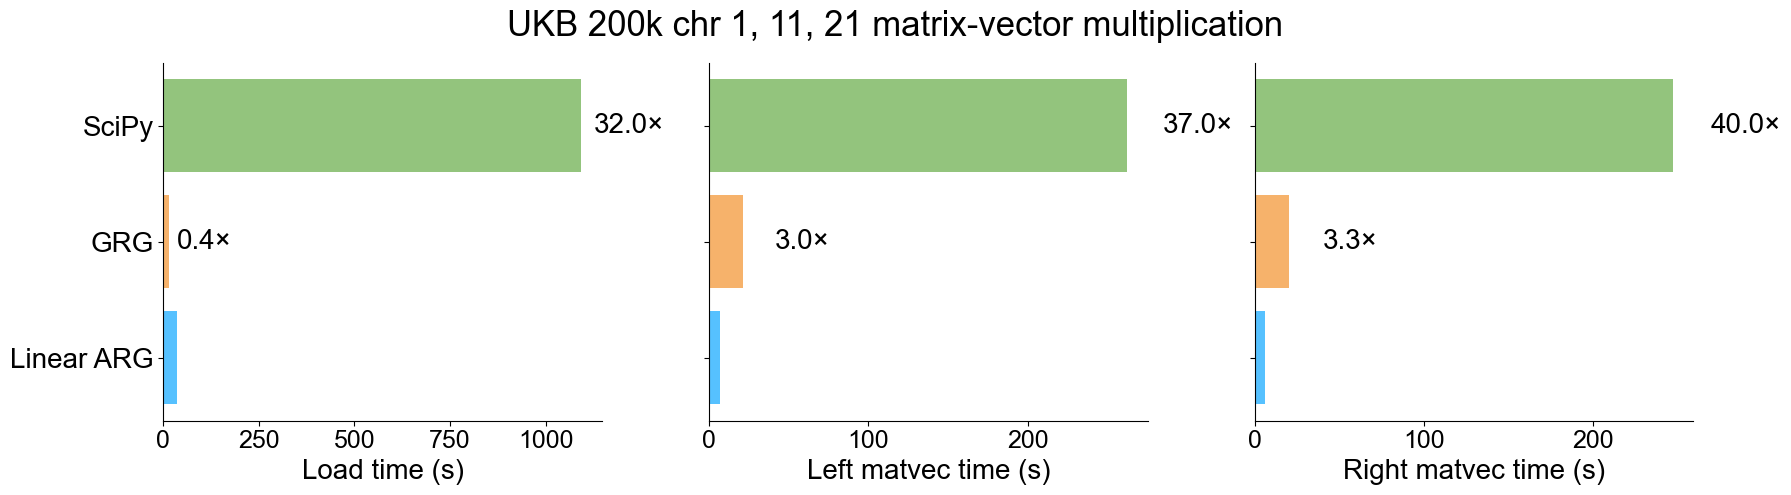

In [ ]:
import matplotlib.pyplot as plt

methods = ['linarg', 'grg', 'scipy']
stats = ['load', 'left', 'right']

color_map = {
    'grg': '#f6b26b',
    'linarg': '#56C1FF',
    'xsi': '#758acf',
    'scipy': '#93c47d',
}

name_map = {
    'grg': 'GRG',
    'linarg': 'Linear ARG',
    'xsi': 'XSI',
    'scipy': 'SciPy',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
axes = axes.flatten()

for i, stat in enumerate(stats):
    ax = axes[i]

    for method in methods:
        if stat == 'left':
            time = df[(df.matmat_type == 'left') & (df.method == method) & (df.n_vectors == 1)].matmat_time.iloc[0]
            linarg_time = df[(df.matmat_type == 'left') & (df.method == 'linarg') & (df.n_vectors == 1)].matmat_time.iloc[0]
        elif stat == 'right':
            time = df[(df.matmat_type == 'right') & (df.method == method) & (df.n_vectors == 1)].matmat_time.iloc[0]
            linarg_time = df[(df.matmat_type == 'right') & (df.method == 'linarg') & (df.n_vectors == 1)].matmat_time.iloc[0]
        else:
            time = df[(df.matmat_type == 'left') & (df.method == method) & (df.n_vectors == 1)].load_time.iloc[0]
            linarg_time = df[(df.matmat_type == 'left') & (df.method == 'linarg') & (df.n_vectors == 1)].load_time.iloc[0]
        
        r = ax.barh(
            name_map[method],
            time,
            color=color_map[method],
        )[0]
        y_center = r.get_y() + r.get_height() / 2.0

        if method != 'linarg':
            x0, x1 = ax.get_xlim()
            dx = 0.01 * (x1 - x0) + 20
            speedup = time / linarg_time
            ax.text(time + dx, y_center, f"{float(f'{speedup:.2g}')}×", va='center', fontsize=20)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if stat == 'load': 
        ax.set_xlabel('Load time (s)', fontsize=20)
    elif stat == 'right':
        ax.set_xlabel('Right matvec time (s)', fontsize=20)
    else:
        ax.set_xlabel('Left matvec time (s)', fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=18)

plt.suptitle('UKB 200k chr 1, 11, 21 matrix-vector multiplication', fontsize=25)
plt.tight_layout()
plt.show()
